In [1]:
# importing libraries
import numpy as np
import pandas as pd

Loading the dataset and processing

In [2]:
# importing dataset of calories and converting it into pandas data frame
df_calories = pd.read_csv('calories_exercise/calories.csv')

In [3]:
df_calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
# importing dataset of exercise and converting it into pandas data frame
df_exercise = pd.read_csv("calories_exercise/exercise.csv")

In [5]:
df_exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
# joining both the datasets
df = pd.merge(df_exercise, df_calories, on='User_ID', how='inner')
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [7]:
df.shape

(15000, 9)

In [8]:
# checking for null values
df.isna().value_counts()

User_ID  Gender  Age    Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
False    False   False  False   False   False     False       False      False       15000
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [10]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Data Analysis

In [11]:
# statistical measures about the data
summary = df.describe()
summary_drop = summary.loc[:, ~summary.columns.isin(['User_ID'])]
summary_drop

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Data Visualization

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df['Gender'].dtype

dtype('O')

In [14]:
sns.set()

<Axes: xlabel='Gender', ylabel='count'>

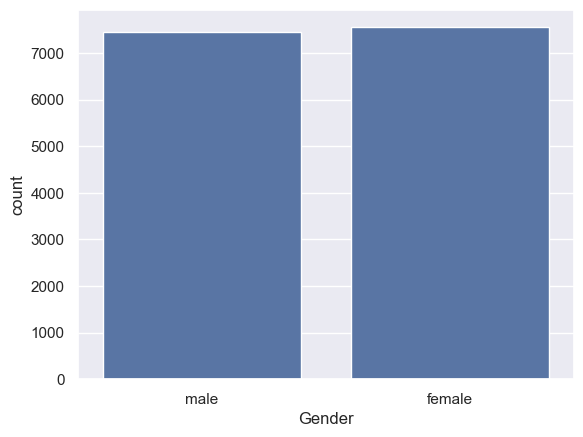

In [15]:
# plt.figure(figsize=(2,2))
sns.countplot(x="Gender", data=df)

<Axes: xlabel='Age', ylabel='Count'>

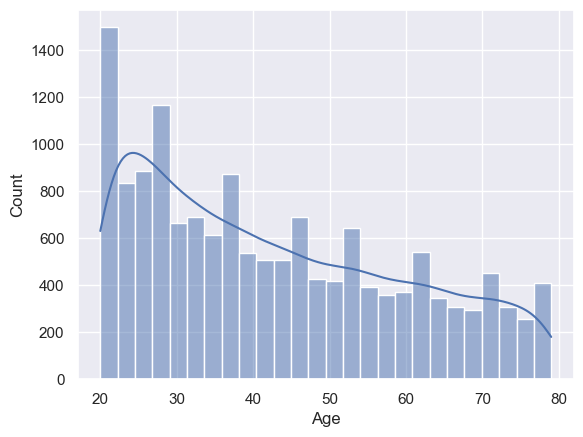

In [16]:
# distribution of Age column
sns.histplot(df['Age'], kde = True)

This is a positively skewed distribution

---



<Axes: xlabel='Height', ylabel='Count'>

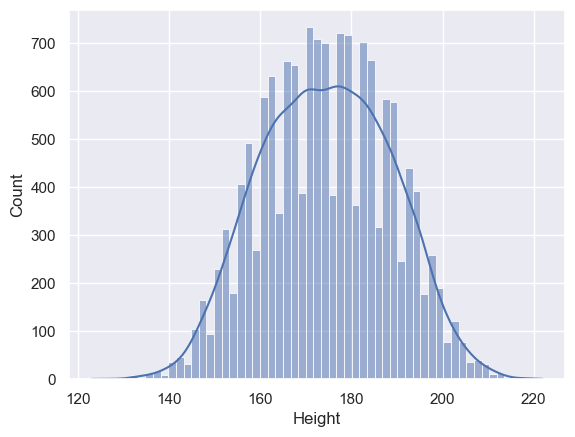

In [17]:
# distribution of Height column
sns.histplot(df['Height'], kde = True)

<Axes: xlabel='Weight', ylabel='Count'>

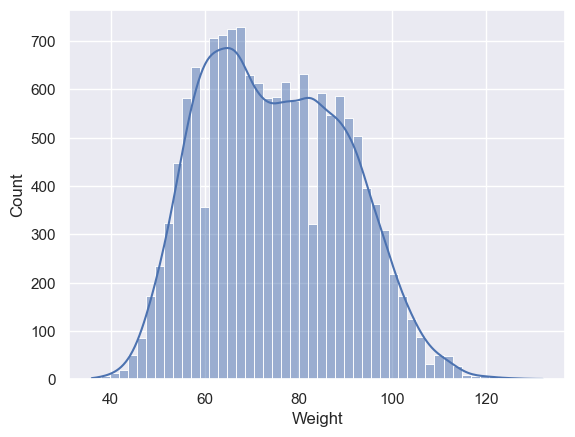

In [18]:
# distribution of w=Weight column
sns.histplot(df['Weight'], kde = True)

<Axes: xlabel='Duration', ylabel='Count'>

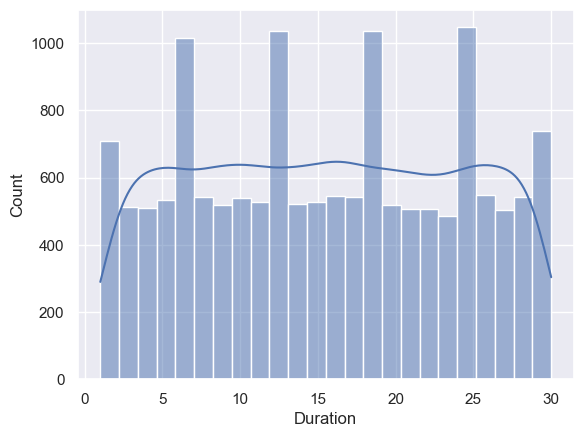

In [19]:
# distribution of Duration column
sns.histplot(df['Duration'], kde = True)

<Axes: xlabel='Heart_Rate', ylabel='Count'>

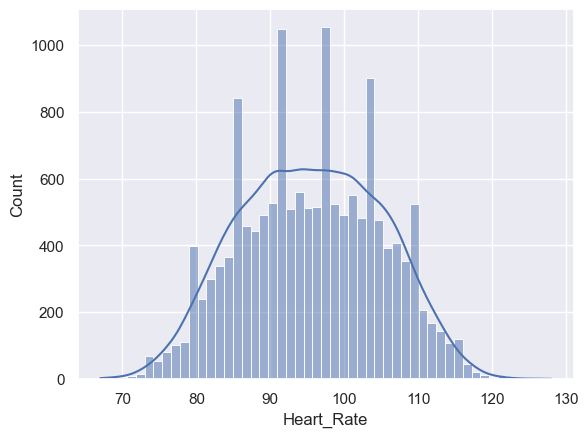

In [20]:
# distribution of Heart_Rate column
sns.histplot(df['Heart_Rate'], kde = True)

<Axes: xlabel='Body_Temp', ylabel='Count'>

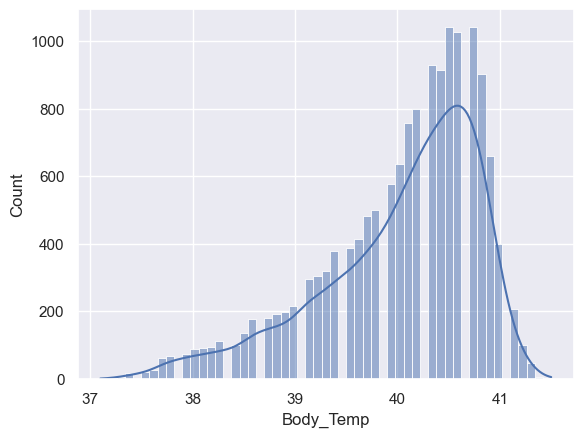

In [21]:
# distribution of body_temp column
sns.histplot(df['Body_Temp'], kde = True)

<Axes: xlabel='Calories', ylabel='Count'>

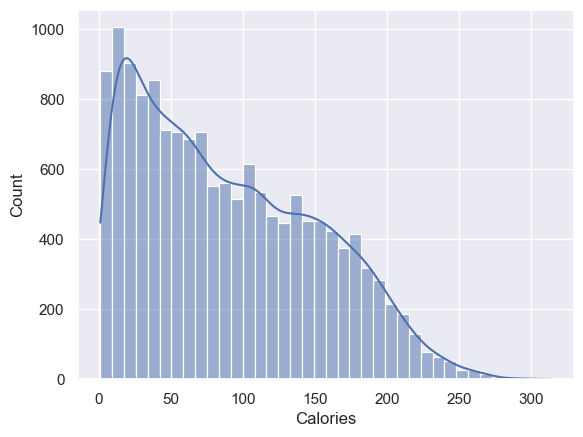

In [22]:
# distribution of calories column
sns.histplot(df['Calories'], kde = True)

Converting the text data to numerical data

In [23]:
df.replace({"Gender":{"male":0,"female":1}}, inplace=True)

C:\Users\Rishabh\AppData\Local\Temp\ipykernel_19768\3500960956.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Gender":{"male":0,"female":1}}, inplace=True)


Finding the Correlation in the dataset
1. Positive Correlation
2. Negative Correlation

In [24]:
correlation = df.corr()

<Axes: >

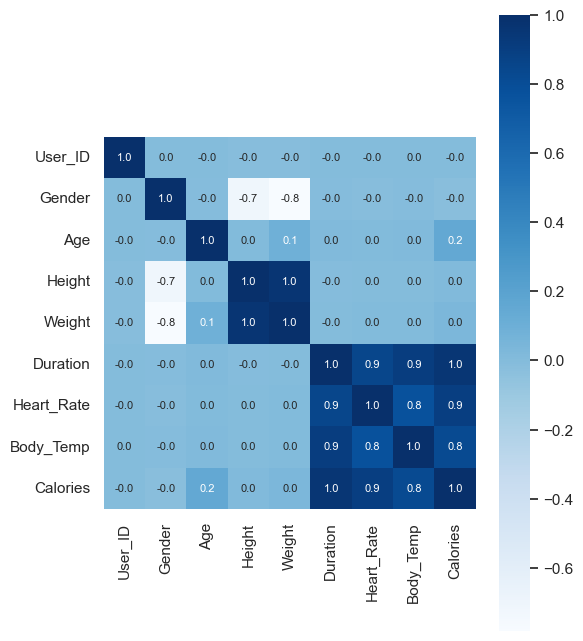

In [25]:
plt.figure(figsize=(6,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap="Blues")

In [26]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
